In [60]:
import os
import json
import numpy as np

import matplotlib.font_manager
matplotlib.font_manager._get_fontconfig_fonts.cache_clear()
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = ["serif"]
plt.rcParams["font.serif"] = ["Times New Roman"]

# ======================================================
#  缓存全局内容：避免每次都重新读 JSON
# ======================================================
_NX_PROP_CACHE = None

def _load_nx_properties():
    """
    从目录 /home/gaochi/leaf_matching/datasets/analysis/nx_properties
    加载所有 JSON 文件。

    JSON 文件格式与你给出的示例完全一致：
    {
      "('cora_ml', 0.1)": {
          "train": {...},
          "whole": {...}
      },
      "('cora_ml', 0.2)": {...},
      ...
    }
    """
    global _NX_PROP_CACHE
    if _NX_PROP_CACHE is not None:
        return _NX_PROP_CACHE


    all_data = {}

    fpath = "/home/gaochi/leaf_matching/datasets/analysis/nx_properties"
    try:
        with open(fpath, "r") as f:
            d = json.load(f)
        # 直接合并字典
        all_data.update(d)
    except Exception as e:
        print(f"[WARN] 无法读取 {fpath}: {e}")

    _NX_PROP_CACHE = all_data
    return _NX_PROP_CACHE


# ======================================================
#   主接口：get_reciprocity(dataset, ratio)
# ======================================================

def get_reciprocity(dataset, ratio):
    """
    输入:
        dataset: str, 如 'cora_ml'
        ratio:   float, 如 0.1

    输出:
        train['reciprocity'] 若存在，否则 np.nan
    """

    all_data = _load_nx_properties()

    # JSON 的键是字符串形式的 Python tuple: "('cora_ml', 0.1)"
    key = f"('{dataset}', {ratio})"

    if key not in all_data:
        # 一些 JSON 可能写成 "('cora_ml', 0.1)" vs "('cora_ml', 0.1)" 格式不一致，
        # 因此我们再尝试 floating 的格式化
        key2 = f"('{dataset}', {float(ratio)})"
        if key2 not in all_data:
            return np.nan
        entry = all_data[key2]
    else:
        entry = all_data[key]

    # 从 entry['train']['reciprocity'] 获取值
    rec = entry["train"]['reciprocity']
    return float(rec)


In [67]:
import os
import numpy as np
import pandas as pd
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression

# ============================================
# 你现有代码中的：目录、算法、数据集、同义字段
# ============================================
algo_dirs = {
    "ours-oi":   "/home/gaochi/leaf_matching/logs_oi/results",
    "ours-oiht": "/home/gaochi/leaf_matching/logs_ht_oi/results",
}

datasets = ['cora', 'citeseer', 'cora_ml',
            'icews18_max', 'twitter', 'ogbl_citation2',
            'yeast', 'male', 'pubmed', 'amazon']

dataset_disp = {
    'cora': 'Cora',
    'citeseer': 'Citeseer',
    'cora_ml': 'Cora-ML',
    'pubmed': 'PubMed',
    'icews18_max': 'ICEWS18',
    'twitter': 'Twitter',
    'ogbl_citation2': 'OGBL-Citation2',
    'yeast': 'Yeast',
    'male': 'C. elegans',
    'amazon': 'Amazon',
}

split_ticks = [0.1]

# ---- 同义词映射 ----
COLUMN_SYNONYMS = {
    'ap': ['ap','AP','pr_auc','pr','PR','pr-auc','average_precision','avg_precision'],
}
SPLIT_COL_CANDIDATES = ['split_ratio','split','ratio']

# ---- 解析 mean±std 的正则 ----
import re
_float_re = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')

def parse_mean_std(x):
    if pd.isna(x):
        return np.nan, 0.0
    if isinstance(x, (int,float,np.number)):
        return float(x),0.0
    s = str(x)
    nums = _float_re.findall(s)
    if not nums:
        return np.nan,0.0
    mean = float(nums[0])
    std  = float(nums[1]) if len(nums)>=2 else 0.0
    return mean,std

def select_column(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def extract_metric_series(df, metric_key):
    col = select_column(df, COLUMN_SYNONYMS[metric_key])
    if col is None:
        raise KeyError(f"没有找到 {metric_key} 列：{df.columns}")
    vs = df[col].tolist()
    return vs

def extract_split_ratio(df):
    col = select_column(df, SPLIT_COL_CANDIDATES)
    if col is None:
        raise KeyError(f"没有 split_ratio 列：{df.columns}")
    return pd.to_numeric(df[col],errors='coerce').to_numpy()



# ============================================
#        主流程：计算 Δ、做拟合、输出结果
# ============================================
print("ratio | pearson_r | slope | trend")
print("---------------------------------------")

for ratio in split_ticks:
    X = []   # reciprocity(d,ratio)
    Y = []   # Δ(d,ratio)

    for d in datasets:

        # --------------------
        # 读取 ours-oi
        # --------------------
        file_oi = os.path.join(algo_dirs["ours-oi"], f"{d}_result.csv")
        if not os.path.isfile(file_oi):
            continue
        df_oi = pd.read_csv(file_oi)
        sr = extract_split_ratio(df_oi)
        ap_oi = extract_metric_series(df_oi,'ap')

        # 找到对应 ratio 的行
        idx = np.where(np.isclose(sr, ratio))[0]
        if len(idx)==0:
            continue
        ap_oi_val = ap_oi[idx[0]]

        # --------------------
        # 读取 ours-oiht
        # --------------------
        file_ht = os.path.join(algo_dirs["ours-oiht"], f"{d}_result.csv")
        if not os.path.isfile(file_ht):
            continue
        df_ht = pd.read_csv(file_ht)
        sr2 = extract_split_ratio(df_ht)
        ap_ht = extract_metric_series(df_ht,'ap')

        idx2 = np.where(np.isclose(sr2, ratio))[0]
        if len(idx2)==0:
            print(f"[WARN] 在 ours-oiht 中找不到 {d} ratio={ratio} 的数据")
            continue
        ap_ht_val = ap_ht[idx2[0]]

        # --------------------
        # 差值 Δ
        # --------------------
        mean_ht_val = parse_mean_std(ap_ht_val)[0]
        mean_oi_val = parse_mean_std(ap_oi_val)[0]
        
        delta = mean_ht_val - mean_oi_val

        # reciprocity
        rec = get_reciprocity(d, ratio)
        print(f"[DEBUG] d={d}, ratio={ratio:.1f}, rec={rec}, Δ={delta}")

        if np.isnan(rec):
            continue

        X.append(rec)
        Y.append(delta)

    # 至少要有两个 dataset 才能算趋势
    if len(X) < 2:
        print(f"{ratio:.1f} | insufficient data")
        continue

    X_arr = np.array(X).reshape(-1,1)
    Y_arr = np.array(Y)

    # 皮尔逊相关系数
    pearson_r,_ = pearsonr(X_arr.ravel(), Y_arr)

    # 线性拟合 Δ = a*rec + b
    reg = LinearRegression().fit(X_arr, Y_arr)
    slope = float(reg.coef_[0])

    trend = "positive" if slope>0 else "negative" if slope<0 else "flat"

    print(f"{ratio:.1f} | {pearson_r:+.4f} | {slope:+.4f} | {trend}")


ratio | pearson_r | slope | trend
---------------------------------------
[DEBUG] d=cora, ratio=0.1, rec=0.003062318174858368, Δ=-2.895700000000005
[DEBUG] d=citeseer, ratio=0.1, rec=0.0, Δ=-0.9871999999999943
[DEBUG] d=cora_ml, ratio=0.1, rec=0.0, Δ=-1.000399999999999
[DEBUG] d=icews18_max, ratio=0.1, rec=0.32890629781504377, Δ=-0.9487999999999985
[DEBUG] d=twitter, ratio=0.1, rec=0.048502672284591236, Δ=-4.026299999999992
[DEBUG] d=ogbl_citation2, ratio=0.1, rec=0.0011310051193321369, Δ=-6.145299999999999
[DEBUG] d=yeast, ratio=0.1, rec=0.0, Δ=4.4572
[DEBUG] d=male, ratio=0.1, rec=0.03766478342749529, Δ=-5.373599999999996
[DEBUG] d=pubmed, ratio=0.1, rec=0.10355329949238579, Δ=-23.291400000000003
[DEBUG] d=amazon, ratio=0.1, rec=0.05411052086032651, Δ=-18.9994
0.1 | -0.0955 | -8.1176 | negative


<Figure size 1000x600 with 0 Axes>

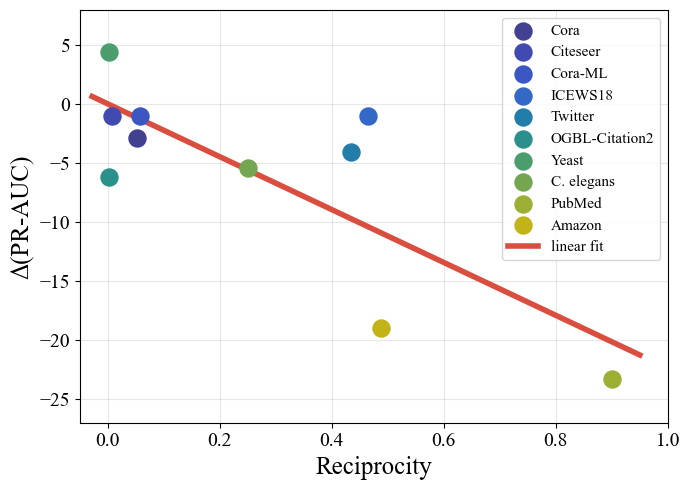

[INFO] 已保存图: ratio_0.1_delta_vs_reciprocity.pdf


In [99]:
from cProfile import label
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ==========================================================
#  前置依赖：
#  你已有：
#    - datasets
#    - split_ticks
#    - extract_metric_series
#    - extract_split_ratio
#    - get_reciprocity
#    - algo_dirs["ours-oi"], algo_dirs["ours-oiht"]
# ==========================================================

plt.figure(figsize=(10, 6))
import colorcet as cc
cmap = cc.gouldian

def extract_metric_series(df, metric_key):
    col = select_column(df, COLUMN_SYNONYMS[metric_key])
    if col is None:
        raise KeyError(f"没有找到 {metric_key} 列：{df.columns}")
    vs = df[col].tolist()
    return vs

def compute_delta_for_ratio(ratio):
    """
    返回该 ratio 下：
    X = reciprocity(d, 0.9)
    Y = Δ = AP_oiht - AP_oi
    """
    X = []
    Y = []

    for d in datasets:
        # ours-oi
        file_oi = os.path.join(algo_dirs["ours-oi"], f"{d}_result.csv")
        if not os.path.isfile(file_oi):
            continue
        df_oi = pd.read_csv(file_oi)
        sr_oi = extract_split_ratio(df_oi)
        ap_oi = extract_metric_series(df_oi, 'ap')
        idx = np.where(np.isclose(sr_oi, ratio))[0]
        if len(idx)==0:
            continue
        ap_oi_val = ap_oi[idx[0]]

        # ours-oiht
        file_ht = os.path.join(algo_dirs["ours-oiht"], f"{d}_result.csv")
        if not os.path.isfile(file_ht):
            continue
        df_ht = pd.read_csv(file_ht)
        sr_ht = extract_split_ratio(df_ht)
        ap_ht = extract_metric_series(df_ht, 'ap')
        idx2 = np.where(np.isclose(sr_ht, ratio))[0]
        if len(idx2)==0:
            continue
        ap_ht_val = ap_ht[idx2[0]]

        # 差值 Δ
        mean_ht_val = parse_mean_std(ap_ht_val)[0]
        mean_oi_val = parse_mean_std(ap_oi_val)[0]
        delta = mean_ht_val - mean_oi_val

        # reciprocity
        rec = get_reciprocity(d, 0.9)
        if np.isnan(rec):
            continue

        X.append(rec)
        Y.append(delta)

    return np.array(X), np.array(Y)


# ==========================================================
#             为每个 ratio 绘制一张图
# ==========================================================

for ratio in split_ticks:

    X, Y = compute_delta_for_ratio(ratio)
    if len(X) < 2:
        print(f"[WARN] ratio={ratio} 数据不足，跳过")
        continue

    # 拟合
    X_fit = X.reshape(-1,1)
    model = LinearRegression().fit(X_fit, Y)
    slope  = float(model.coef_[0])
    inter  = float(model.intercept_)
    pearson_r, _ = pearsonr(X, Y)

    # 绘制
    plt.figure(figsize=(7,5))
    
    color = [
        cmap[int((0.1 + 0.6 * (i + 1) / len(datasets)) * (len(cmap) - 1))] 
        for i in range(len(datasets))
    ]
    labels = [
        dataset_disp.get(datasets[i], datasets[i])
        for i in range(len(datasets))
    ]
    
    x_line = np.linspace(min(X) -0.03, max(X) + 0.05, 200)
    y_line = slope * x_line + inter
    
    for i in range(len(X)):
        plt.scatter(X[i], Y[i], s=150, color=color[i], zorder=5, label=labels[i])
    plt.plot(x_line, y_line, color="#da4e3f", linewidth=4, label='linear fit')
    
    # 拟合线
    
    

    # 标注
    plt.xlabel("Reciprocity", fontsize=18)
    plt.ylabel("Δ(PR-AUC)", fontsize=18)

    # plt.text(
    #     0.02, 0.95,
    #     f"Pearson r = {pearson_r:+.3f}\nSlope = {slope:+.4f}",
    #     transform=plt.gca().transAxes,
    #     fontsize=14,
    #     verticalalignment='top'
    # )

    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.xlim(-0.05,1.0)
    plt.ylim(-27, 8)
    plt.tick_params(axis='both', labelsize=14)
    out_path = f"ratio_{ratio}_delta_vs_reciprocity.pdf"
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()

    print(f"[INFO] 已保存图: {out_path}")


In [ ]:
# ==========================================================
#      全部 ratio 合并 — 全局散点图 + 全局线性拟合
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

# ----------- 累积所有 ratio 的点 ---------------
X_all = []
Y_all = []

for ratio in [0.7,0.8,0.9]:
    X, Y = compute_delta_for_ratio(ratio)
    if len(X) == 0:
        continue
    X_all.append(X)
    Y_all.append(Y)

if len(X_all)==0:
    print("[ERROR] 无任何数据可用于全局拟合")
else:
    X_all = np.concatenate(X_all)
    Y_all = np.concatenate(Y_all)

    # ------------------------------
    # 全局拟合
    # ------------------------------
    X_fit = X_all.reshape(-1,1)
    model = LinearRegression().fit(X_fit, Y_all)
    slope  = float(model.coef_[0])
    inter  = float(model.intercept_)
    pearson_r,_ = pearsonr(X_all, Y_all)

    # ------------------------------
    # 绘图
    # ------------------------------
    plt.figure(figsize=(7,5))
    plt.scatter(X_all, Y_all, s=55, color='blue', alpha=0.6, label="all datasets & ratios")

    # 拟合直线
    x_line = np.linspace(min(X_all), max(X_all), 300)
    y_line = slope * x_line + inter
    plt.plot(x_line, y_line, color='red', linewidth=2.6, label="global fit")

    # 注释
    plt.title("Global Δ(PR-AUC) vs Reciprocity (all ratios combined)", fontsize=18)
    plt.xlabel("Reciprocity", fontsize=16)
    plt.ylabel("Δ(PR-AUC) = AP_oiht - AP_oi", fontsize=16)

    plt.text(
        0.02, 0.95,
        f"Pearson r = {pearson_r:+.3f}\nSlope = {slope:+.4f}",
        transform=plt.gca().transAxes,
        fontsize=14,
        verticalalignment='top'
    )

    plt.legend(fontsize=14)
    plt.grid(alpha=0.3)
    plt.ylim(-25, 25)
    # plt.xscale('log')

    out_path = "global_delta_vs_reciprocity.pdf"
    plt.tight_layout()
    plt.show()
    print(f"[INFO] 全局拟合图已保存：{out_path}")
    print(f"[INFO] Pearson r = {pearson_r:+.4f}, Slope = {slope:+.6f}")


[ERROR] 无任何数据可用于全局拟合


[0.11487145 0.11831931 0.18758273 0.16850356 0.25317514 0.20477102
 0.27978038 0.35103061 0.43510486]
[0.58674185 0.5635539  0.34237459 0.36151532 0.8780777  0.75816951
 0.57498954 0.73706826 1.16860035]
[0.24313716 0.37489841 0.29453103 0.52694615 0.55456552 0.75231709
 0.9201896  1.10345177 1.2518367 ]
[0.16266407 0.16857737 0.25520159 0.27840578 0.1809312  0.31419811
 0.34714954 0.38835788 0.3483324 ]
[0.18620604 0.16797074 0.16953068 0.20199584 0.11518233 0.11378409
 0.18182035 0.15950887 0.13848148]
[0.1708017  0.07484504 0.07985299 0.08934859 0.10850622 0.05603508
 0.04394235 0.03239753 0.03318825]
[0.73516901 0.77634329 1.27117886 0.93150827 0.89462409 0.55617379
 0.70738791 1.24130548 1.001281  ]
[0.5663826  0.39642989 0.63829919 0.88124203 0.89941617 1.61186308
 1.92265173 1.52601968 2.6065292 ]
[0.19218928 0.41780857 0.35227156 0.48887831 0.22029809 0.23411393
 0.18303511 0.2308987  0.18949156]
[0.06208253 0.02828887 0.03368679 0.02496157 0.04260516 0.06520498
 0.05534736 0.0

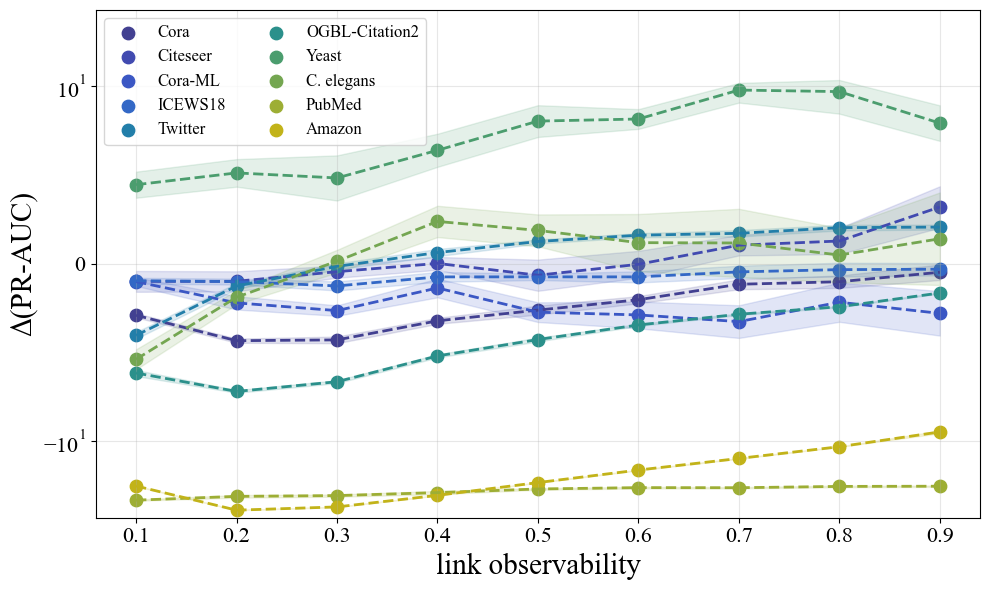

In [105]:
# ==========================================================
#     绘制：横轴 ratio，纵轴 Δ(PR-AUC)，每条曲线一个 dataset
#     + 添加方差/标准差的可视化
# ==========================================================
from re import split
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

split_ticks = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

def clean_value4mean(value):
    s = str(value)
    if '±' in s:
        return float(s.split('±')[0])
    return float(s)

def clean_value4std(value):
    s = str(value)
    if '±' in s:
        return float(s.split('±')[1])
    return 0.0

def extract_metric_series(df, metric_key):
    col = select_column(df, COLUMN_SYNONYMS[metric_key])
    if col is None:
        raise KeyError(f"没有找到 {metric_key} 列：{df.columns}")
    vs = df[col].tolist()
    return vs

def compute_delta_series_for_dataset(dataset):
    """
    对单个 dataset，遍历所有 ratio，返回：
        ratios_used：实际有数据的 ratio 列表
        deltas：对应的 Δ(均值)
        deltas_std：对应的 Δ 的标准差（通过误差传播计算）
    """
    ratios_used = []
    deltas = []
    deltas_std = []

    for ratio in split_ticks:
        # ---- ours-oi ----
        file_oi = os.path.join(algo_dirs["ours-oi"], f"{dataset}_result.csv")
        if not os.path.isfile(file_oi):
            continue
        df_oi = pd.read_csv(file_oi)
        sr_oi = extract_split_ratio(df_oi)
        
        # 提取 ap 的均值和标准差
        ap_oi_raw = extract_metric_series(df_oi, 'ap')
        ap_oi = np.array([clean_value4mean(v) for v in ap_oi_raw])
        ap_oi_std = np.array([clean_value4std(v) for v in ap_oi_raw])
        
        idx_oi = np.where(np.isclose(sr_oi, ratio))[0]
        if len(idx_oi) == 0:
            continue
        ap_oi_val = ap_oi[idx_oi[0]]
        ap_oi_std_val = ap_oi_std[idx_oi[0]]

        # ---- ours-oiht ----
        file_ht = os.path.join(algo_dirs["ours-oiht"], f"{dataset}_result.csv")
        if not os.path.isfile(file_ht):
            continue
        df_ht = pd.read_csv(file_ht)
        sr_ht = extract_split_ratio(df_ht)
        
        # 提取 ap 的均值和标准差
        ap_ht_raw = extract_metric_series(df_ht, 'ap')
        ap_ht = np.array([clean_value4mean(v) for v in ap_ht_raw])
        ap_ht_std = np.array([clean_value4std(v) for v in ap_ht_raw])
        
        idx_ht = np.where(np.isclose(sr_ht, ratio))[0]
        if len(idx_ht) == 0:
            continue
        ap_ht_val = ap_ht[idx_ht[0]]
        ap_ht_std_val = ap_ht_std[idx_ht[0]]

        # 计算 delta 的均值和标准差
        delta = ap_ht_val - ap_oi_val
        # 误差传播：Δ 的方差 = Var(ht) + Var(oi)
        delta_std = np.sqrt(ap_ht_std_val**2 + ap_oi_std_val**2)

        ratios_used.append(ratio)
        deltas.append(delta)
        deltas_std.append(delta_std)

    return np.array(ratios_used), np.array(deltas), np.array(deltas_std)


# ----------------------------------------------------------
#              绘制所有 dataset 的 ratio-delta 曲线（带误差）
# ----------------------------------------------------------
plt.figure(figsize=(10, 6))
import colorcet as cc
cmap = cc.gouldian

datasets = ['cora', 'citeseer', 'cora_ml',
            'icews18_max', 'twitter', 'ogbl_citation2',
            'yeast', 'male', 'pubmed', 'amazon']

dataset_disp = {
    'cora': 'Cora',
    'citeseer': 'Citeseer',
    'cora_ml': 'Cora-ML',
    'pubmed': 'PubMed',
    'icews18_max': 'ICEWS18',
    'twitter': 'Twitter',
    'ogbl_citation2': 'OGBL-Citation2',
    'yeast': 'Yeast',
    'male': 'C. elegans',
    'amazon': 'Amazon',
}

for i, d in enumerate(datasets):
    rts, dlt, dlt_std = compute_delta_series_for_dataset(d)

    if len(rts) == 0:
        print(f"[WARN] dataset={d} 无数据，跳过")
        continue
    color = cmap[int((0.1 + 0.6 * (i + 1) / len(datasets)) * (len(cmap) - 1))]    
    # 绘制主曲线
    plt.plot(
        rts, dlt,
        linestyle="--",
        linewidth=2,
        color=color,
        
    )
    
    # 绘制散点
    plt.scatter(rts, dlt, color=color, s=80, label=dataset_disp.get(d, d))
    print(dlt_std)
    
    # 绘制误差带（fill_between，半透明区域）
    plt.fill_between(
        rts, 
        dlt - dlt_std,  # 下界
        dlt + dlt_std,  # 上界
        color=color,
        alpha=0.15      # 透明度
    )

plt.xlabel("link observability", fontsize=21)
plt.ylabel("Δ(PR-AUC)", fontsize=21)

plt.xticks(split_ticks)
plt.grid(alpha=0.3)
plt.legend(fontsize=12, ncol=2, loc='upper left')

plt.yscale('symlog', linthresh=10.0)
plt.ylim([-30, 30])

plt.tick_params(axis='both', labelsize=16)

plt.tight_layout()

out_path = "delta_vs_ratio_by_dataset_with_std.pdf"
plt.savefig(out_path)
plt.show()